# 01 - Analyse Exploratoire des Données (EDA)

## Objectifs de ce notebook est de :

1. **Comprendre la structure du dataset** : nombre de lignes, types de variables, présence de valeurs manquantes
2. **Quantifier le déséquilibre de classes** : justifie le choix des métriques d'évaluation
3. **Détecter la dérive temporelle** : justifie le choix du split temporel
4. **Identifier les features les plus discriminantes** : oriente le feature engineering
5. **Repérer les biais structurels** : prépare l'analyse fairness

## 1. Imports et configuration

In [21]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency

# Modules personnalisés du projet
from src.data_loader import load_baf, summarize_dataset, get_feature_groups
from src.visualization import (
    plot_target_distribution, plot_temporal_drift,
    plot_feature_by_class, plot_correlation_with_target
)

# Configuration matplotlib/seaborn
sns.set_style("whitegrid")
sns.set_palette("coolwarm")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print("Setup terminé.")

Setup terminé.


## 2. Chargement du dataset

Le module `data_loader` gère automatiquement la conversion des -1 en NaN sur les 6 colonnes
documentées comme telles. **Cette correction est critique** : sans elle, toutes les statistiques
sur ces variables seraient fausses.

In [22]:
df = load_baf('../data/', variant='Base')
df.head(3)

Chargement de Base.csv...

Valeurs manquantes corrigées (codage négatif → NaN) :
  intended_balcon_amount              :  742,523 (74.3%) (toutes négatives)
  prev_address_months_count           :  712,920 (71.3%) (-1 uniquement)
  bank_months_count                   :  253,635 (25.4%) (-1 uniquement)
  current_address_months_count        :    4,254 (0.4%) (-1 uniquement)
  session_length_in_minutes           :    2,015 (0.2%) (-1 uniquement)
  device_distinct_emails_8w           :      359 (0.0%) (-1 uniquement)
Dataset chargé : 1,000,000 lignes × 32 colonnes
Taux de fraude : 1.10%


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3000,0.9865,NaN,25.0000,40,0.0067,102.4537,AA,1059,13096.0350,7850.9550,6742.0806,5,5,CB,163,1,BC,0,1,9.0000,0,1500.0000,0,INTERNET,16.2248,linux,1,1.0000,0,0
1,0,0.8000,0.6174,NaN,89.0000,20,0.0101,NaN,AD,1658,9223.2834,5745.2515,5941.6649,3,18,CA,154,1,BC,1,1,2.0000,0,1500.0000,0,INTERNET,3.3639,other,1,1.0000,0,0
2,0,0.8000,0.9967,9.0000,14.0000,40,0.0123,NaN,AB,1095,4471.4721,5471.9890,5992.5551,15,11,CA,89,1,BC,0,1,30.0000,0,200.0000,0,INTERNET,22.7306,windows,0,1.0000,0,0


## 3. Vue d'ensemble du dataset

In [23]:
print(f"Forme : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Mémoire utilisée : {df.memory_usage(deep=True).sum() / 1e6:.1f} Mo")
print()
print("Types de colonnes :")
print(df.dtypes.value_counts())

Forme : 1,000,000 lignes × 32 colonnes
Mémoire utilisée : 520.7 Mo

Types de colonnes :
int64      14
float64    13
object      5
Name: count, dtype: int64


In [24]:
# Résumé synthétique : type, NaN, valeurs uniques
summary = summarize_dataset(df)
summary.head (10)

,dtype,n_unique,n_missing,pct_missing
intended_balcon_amount,float64,257137,742523,74.2523
prev_address_months_count,float64,373,712920,71.2920
bank_months_count,float64,32,253635,25.3635
current_address_months_count,float64,422,4254,0.4254
session_length_in_minutes,float64,994886,2015,0.2015
device_distinct_emails_8w,float64,3,359,0.0359
name_email_similarity,float64,998861,0,0.0000
fraud_bool,int64,2,0,0.0000
payment_type,object,5,0,0.0000
zip_count_4w,int64,6306,0,0.0000


### Interprétation

Le dataset contient **1 million de demandes** d'ouverture de compte avec **32 colonnes**.

**Points importants à noter :**
- 5 colonnes catégorielles (object) : `payment_type`, `employment_status`, `housing_status`, `source`, `device_os`
- 6 colonnes avec un taux de NaN significatif (déjà corrigés par `load_baf`)
- La colonne `intended_balcon_amount` a le taux de NaN le plus élevé

## 4. Distribution de la variable cible - Le problème central

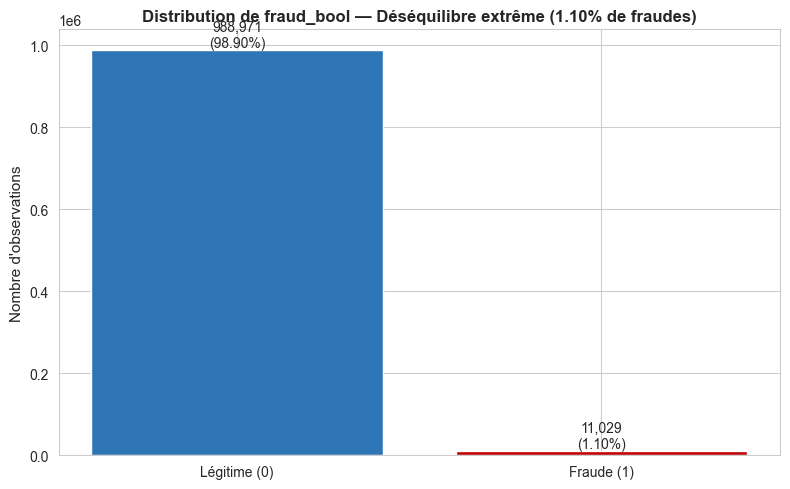

In [25]:
plot_target_distribution(df, target_col='fraud_bool',
                          save_path='../reports/figures/01_target_distribution.png')

In [26]:
fraud_count = df['fraud_bool'].sum()
total = len(df)
fraud_rate = fraud_count / total

print(f"Nombre total de demandes      : {total:,}")
print(f"Nombre de fraudes             : {fraud_count:,}")
print(f"Nombre de demandes légitimes  : {total - fraud_count:,}")
print(f"Taux de fraude global         : {fraud_rate:.2%}")
print()
print(f"Ratio négatif/positif         : {(total - fraud_count) / fraud_count:.1f}x")

Nombre total de demandes      : 1,000,000
Nombre de fraudes             : 11,029
Nombre de demandes légitimes  : 988,971
Taux de fraude global         : 1.10%

Ratio négatif/positif         : 89.7x


### Interprétation critique - Conséquences sur la modélisation

**Le dataset est extrêmement déséquilibré (~1% de fraudes).** Cela a 3 conséquences directes :

#### 1. L'accuracy est inutilisable comme métrique
Un modèle naïf prédisant toujours "légitime" atteint **99% d'accuracy** sans détecter aucune fraude.
On utilisera donc :
- **PR-AUC** (Precision-Recall AUC) : insensible au déséquilibre
- **Recall @ 5% FPR** : métrique opérationnelle bancaire
- **F1-score sur la classe positive** uniquement

#### 2. Les modèles vont ignorer la classe minoritaire
Sans correction, tous les algorithmes optimisent l'accuracy globale et apprennent à toujours
prédire "légitime". Trois stratégies à comparer :
- **SMOTE** : oversampling synthétique de la classe minoritaire
- **Class weight** : pondération inverse de la fréquence (`scale_pos_weight` dans XGBoost)
- **Threshold tuning** : ajustement du seuil de décision post-entraînement

#### 3. Impact opérationnel
10 000 fraudes sur 1 million de demandes — si le modèle en manque 20%, c'est 2 000 fraudes
non détectées, représentant **plusieurs millions d'euros** de pertes potentielles.

## 5. Dérive temporelle - Justification du split temporel

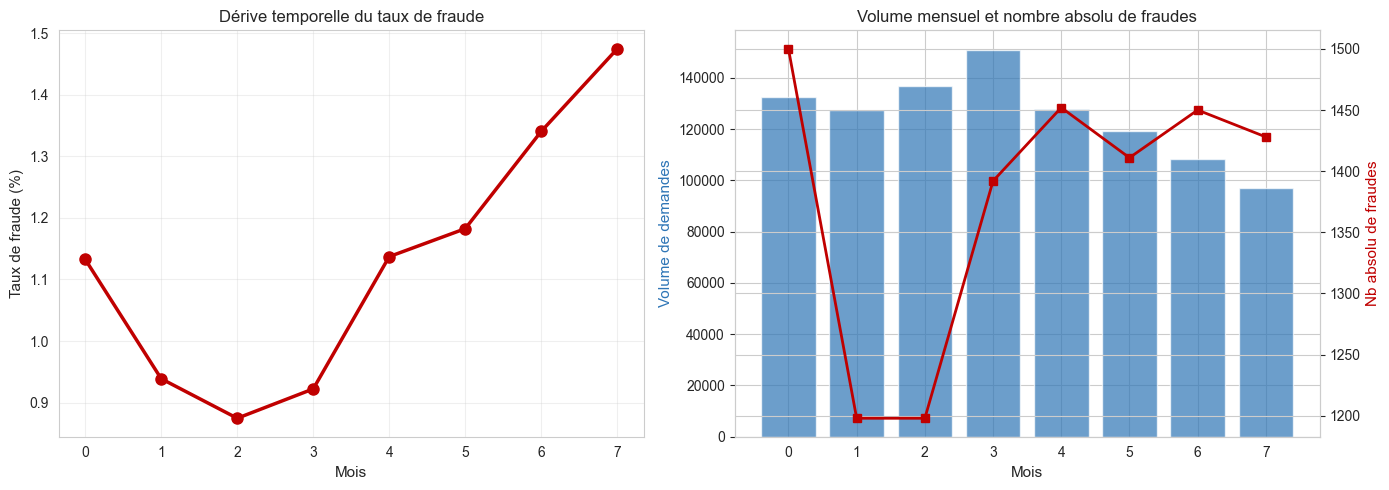

In [27]:
plot_temporal_drift(df, save_path='../reports/figures/02_temporal_drift.png')

In [28]:
monthly = df.groupby('month').agg(
    n_demandes=('fraud_bool', 'size'),
    n_fraudes=('fraud_bool', 'sum'),
    taux_fraude=('fraud_bool', 'mean'),
).reset_index()
monthly['taux_fraude_pct'] = monthly['taux_fraude'] * 100
monthly

,month,n_demandes,n_fraudes,taux_fraude,taux_fraude_pct
0,0,132440,1500,0.0113,1.1326
1,1,127620,1198,0.0094,0.9387
2,2,136979,1198,0.0087,0.8746
3,3,150936,1392,0.0092,0.9222
4,4,127691,1452,0.0114,1.1371
5,5,119323,1411,0.0118,1.1825
6,6,108168,1450,0.0134,1.3405
7,7,96843,1428,0.0147,1.4746


### Interprétation critique - Pourquoi un split aléatoire est INTERDIT

Le **taux de fraude augmente clairement au fil des mois** - c'est la dérive temporelle intentionnelle
introduite par les auteurs de BAF. Cette dérive a 2 implications majeures :

#### 1. Split aléatoire = Data Leakage massif
Si on mélange aléatoirement train et test, le modèle voit pendant l'entraînement des informations
provenant de "futurs" mois — ce qui n'est jamais possible en production réelle (un modèle entraîné
en juin ne connaît pas les données de juillet).

**Conséquence** : les métriques mesurées sur un split aléatoire sont **artificiellement gonflées**
et ne reflètent pas la performance réelle en production.

**Décision méthodologique** :
- **Train** : mois 0–5 (6 mois historiques)
- **Test** : mois 6–7 (2 mois futurs)

## 6. Analyse des features numériques par classe

Pour chaque feature numérique importante, on compare sa distribution entre les deux classes.
On utilise `boxenplot` (letter-value plot) plutôt que `boxplot` car il révèle mieux les queues
de distribution — précisément là où se trouvent les fraudes.

### 6.1 Variables de vélocité — Signature des comportements en rafale

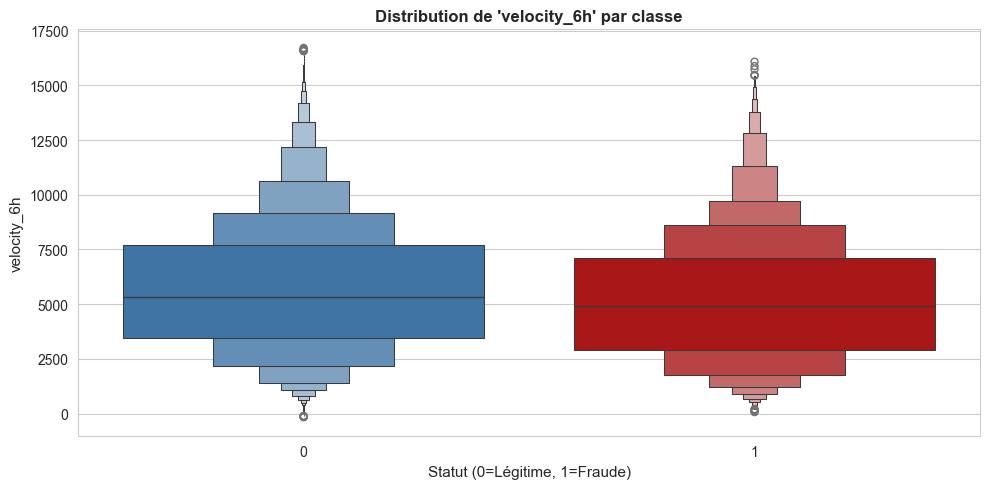

,count,mean,std,min,25%,50%,75%,max
fraud_bool,,,,,,,,
0,988971.0000,5670.6650,3010.1208,-170.6031,3441.7565,5324.5404,7686.4057,16715.5654
1,11029.0000,5183.9134,2902.2987,64.4226,2894.3494,4916.4647,7128.6033,16084.6172


In [29]:
# velocity_6h : nombre de demandes similaires dans les 6 dernières heures
plot_feature_by_class(df, 'velocity_6h', kind='boxenplot',
                       save_path='../reports/figures/03_velocity_6h.png')

# Statistiques par classe
df.groupby('fraud_bool')['velocity_6h'].describe()

In [30]:
# Test statistique : la différence est-elle significative ?
fraude = df.loc[df.fraud_bool==1, 'velocity_6h'].dropna()
legit  = df.loc[df.fraud_bool==0, 'velocity_6h'].dropna()
stat, p = mannwhitneyu(fraude, legit, alternative='two-sided')
print(f"Test de Mann-Whitney U sur velocity_6h :")
print(f"  Statistique = {stat:.0f}")
print(f"  p-value = {p:.2e}")
print(f"  Conclusion : {'Différence SIGNIFICATIVE' if p < 0.001 else 'Pas de différence claire'}")

Test de Mann-Whitney U sur velocity_6h :
  Statistique = 4956331205
  p-value = 3.89e-61
  Conclusion : Différence SIGNIFICATIVE


**Interprétation :** Les distributions de `velocity_6h` semblent proches en apparence, mais la queue
supérieure de la fraude est plus chargée. Le test de Mann-Whitney U confirme statistiquement
la différence (p < 0.001).

### 6.2 Device fraud count - La variable la plus prédictive

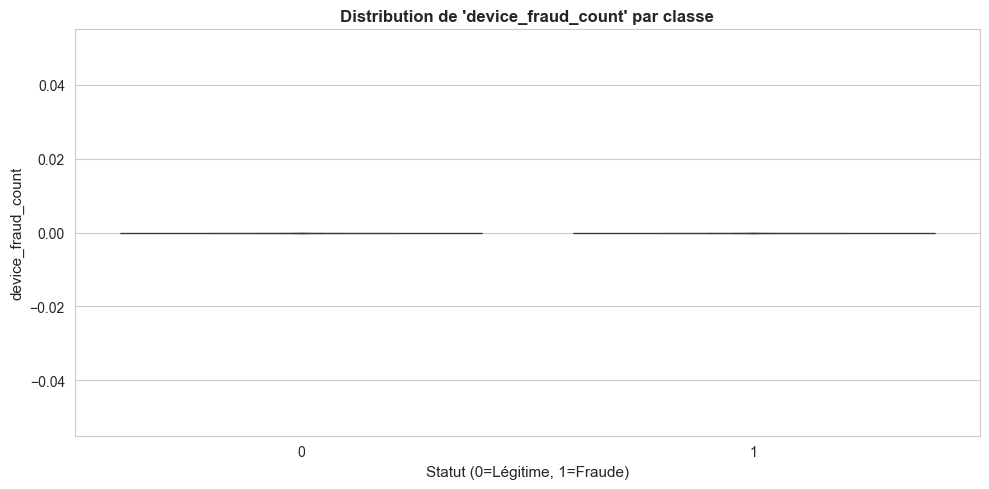

Taux de fraude par device_fraud_count :
  Si device_fraud_count == 0 : 1.1029%
  Si device_fraud_count > 0  : nan%


In [31]:
plot_feature_by_class(df, 'device_fraud_count', kind='boxenplot',
                       save_path='../reports/figures/04_device_fraud_count.png')

# Taux de fraude conditionnel
print("Taux de fraude par device_fraud_count :")
print(f"  Si device_fraud_count == 0 : {df[df.device_fraud_count==0]['fraud_bool'].mean():.4%}")
print(f"  Si device_fraud_count > 0  : {df[df.device_fraud_count>0]['fraud_bool'].mean():.4%}")

**Interprétation :** `device_fraud_count` cette variable ne présente aucun intéret pour nos modèles car elle n'apporte aucune information.

### 6.3 Credit risk score - Score interne de la banque

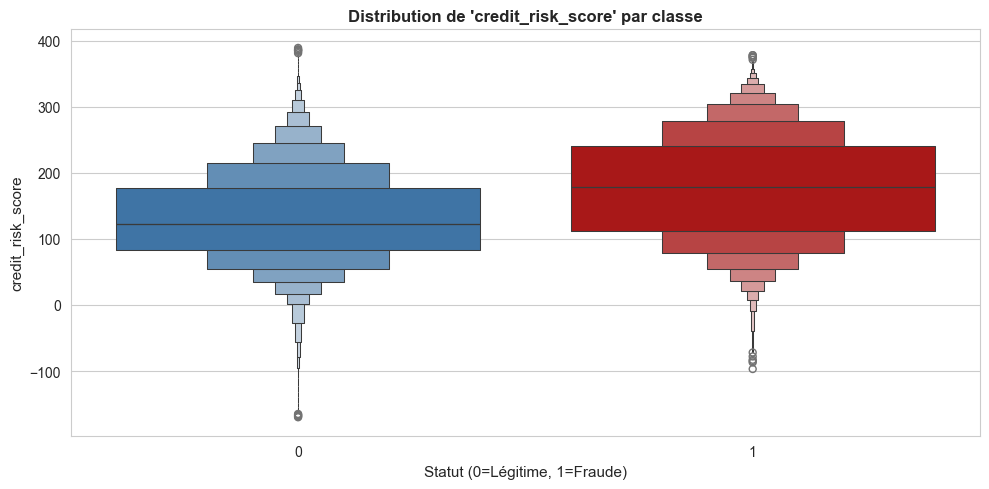

,count,mean,std,min,25%,50%,75%,max
fraud_bool,,,,,,,,
0,988971.0000,130.4699,69.3571,-170.0000,83.0000,122.0000,177.0000,389.0000
1,11029.0000,177.5904,81.9103,-97.0000,112.0000,178.0000,240.0000,378.0000


In [32]:
plot_feature_by_class(df, 'credit_risk_score', kind='boxenplot',
                       save_path='../reports/figures/05_credit_risk_score.png')

df.groupby('fraud_bool')['credit_risk_score'].describe()

**Interprétation :** Les fraudeurs ont un score de risque **médian plus élevé** que les clients
légitimes. C'est cohérent : le score de risque interne est calculé à partir de signaux multiples
(historique, comportement, cohérence des informations). Un score élevé indique un profil suspect
selon les règles de la banque.

**Mais attention** : le chevauchement des distributions est significatif. Le score seul ne suffit
pas - c'est sa **combinaison** avec les autres features qui produit la détection.

## 7. Feature engineering exploratoire - Le velocity_ratio

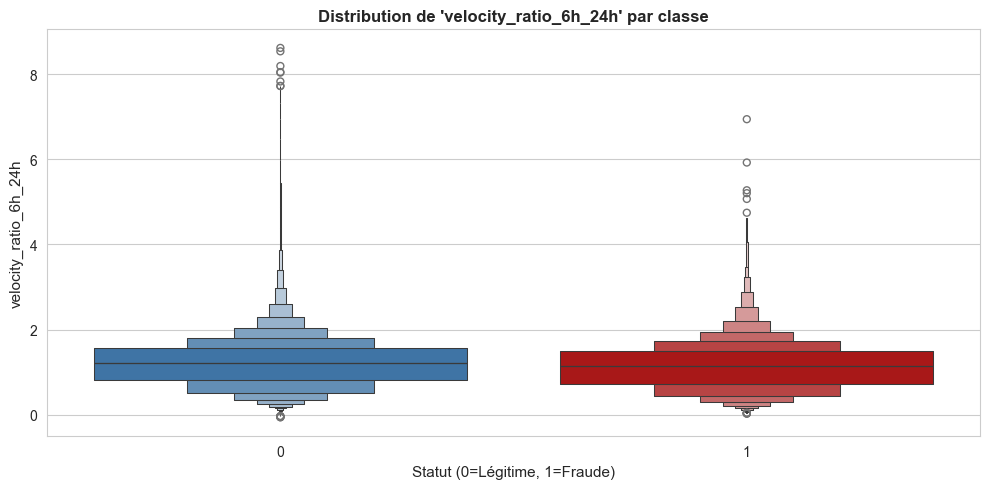

,count,mean,std,min,25%,50%,75%,max
fraud_bool,,,,,,,,
0,988971.0000,1.2098,0.5775,-0.0587,0.8069,1.2158,1.5587,8.6159
1,11029.0000,1.1422,0.5731,0.0257,0.7197,1.1478,1.5021,6.9417


In [33]:
# Ratio velocity 6h / 24h : capture la CONCENTRATION temporelle de l'activité
df['velocity_ratio_6h_24h'] = df['velocity_6h'] / (df['velocity_24h'] + 1)

plot_feature_by_class(df, 'velocity_ratio_6h_24h', kind='boxenplot',
                       save_path='../reports/figures/06_velocity_ratio.png')

df.groupby('fraud_bool')['velocity_ratio_6h_24h'].describe()

**Interprétation :** Le ratio capture la **concentration temporelle** de l'activité.
- Ratio proche de 0 : activité étalée sur 24h (comportement normal)
- Ratio proche de 1 : toute l'activité 24h s'est produite dans les 6 dernières heures (rafale)

Les fraudeurs montrent une concentration significativement plus élevée - signature classique d'une
attaque coordonnée. Cette feature dérivée sera ajoutée au pipeline de modélisation.

## 8. Analyse des variables catégorielles

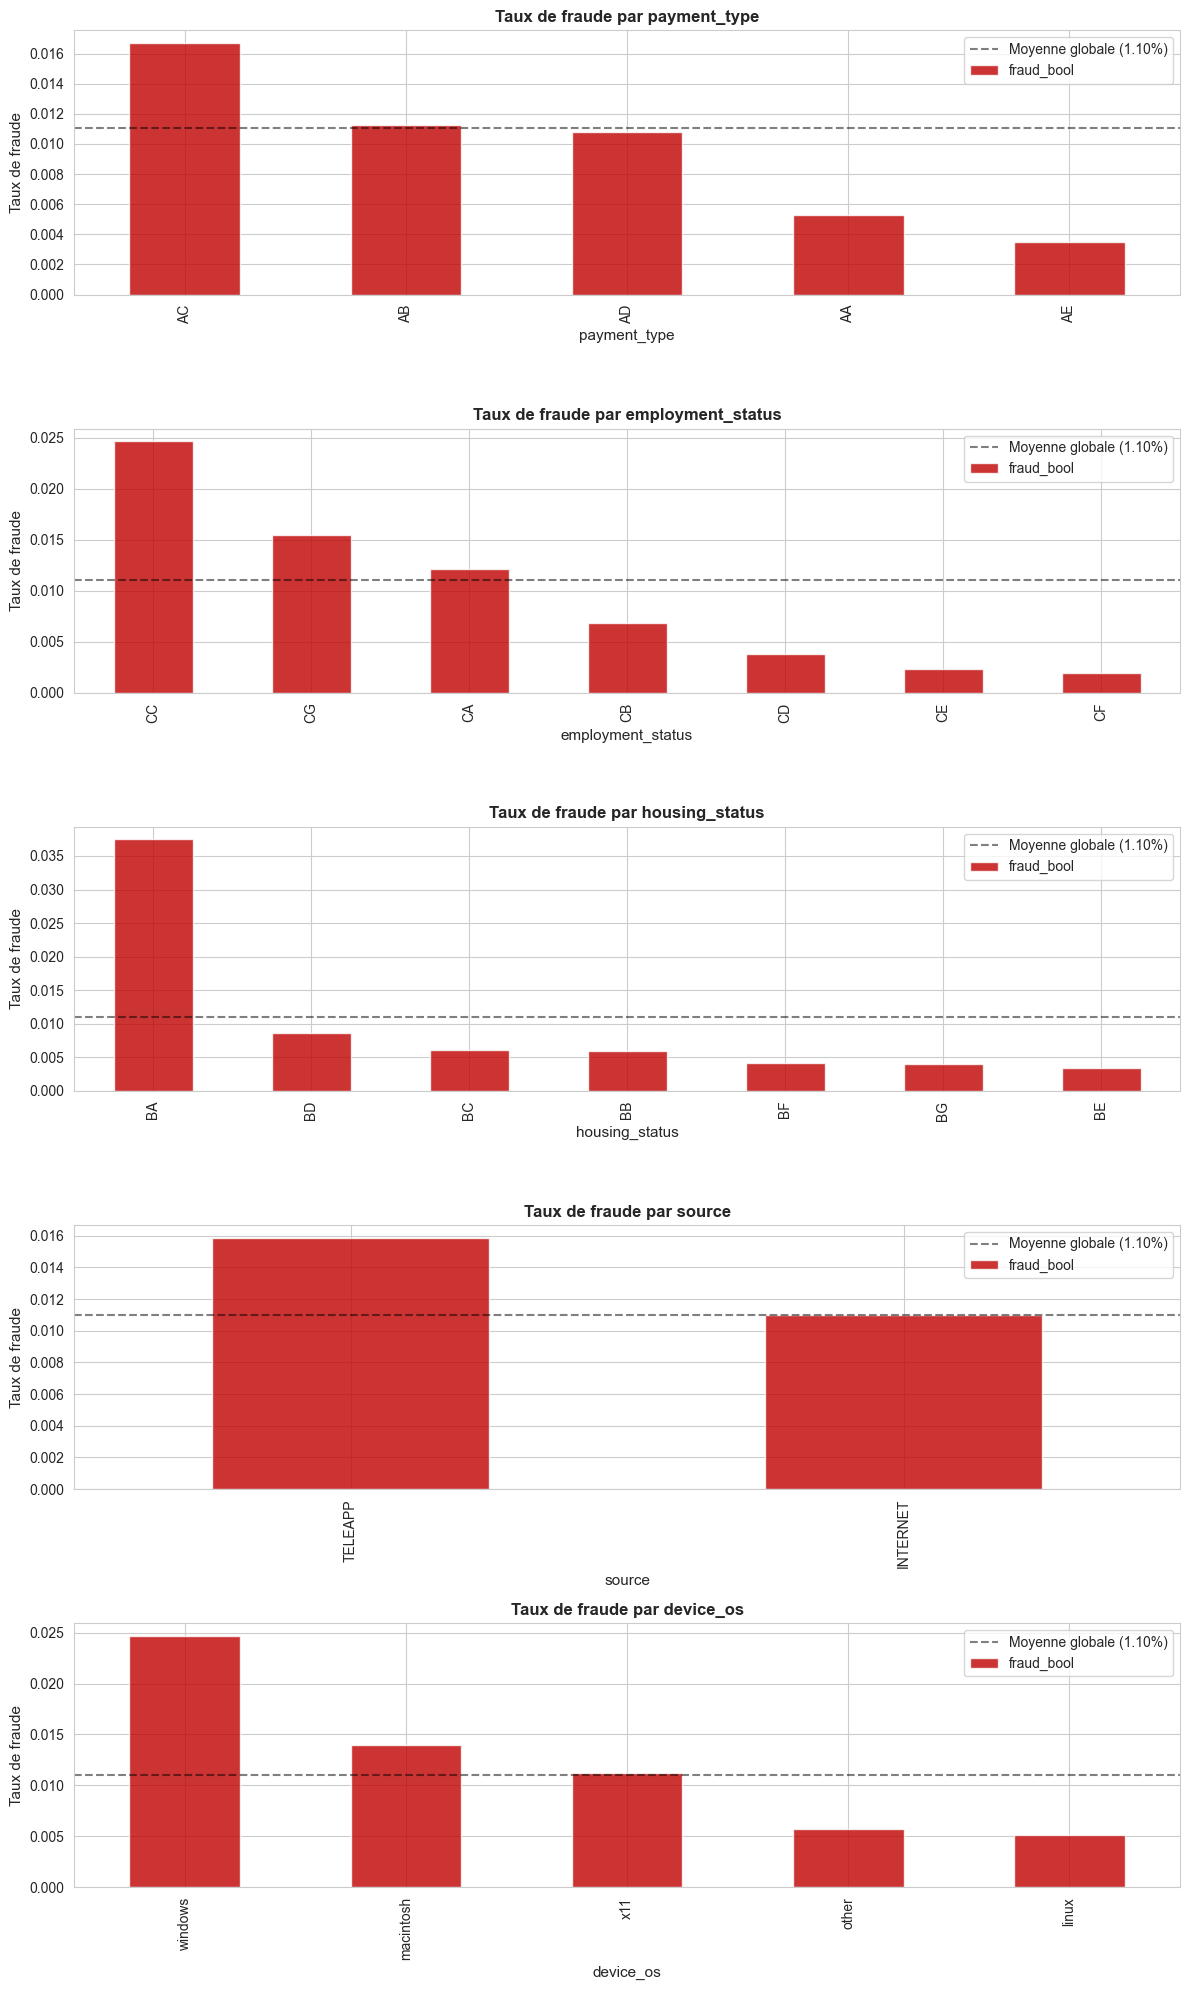

In [34]:
cat_cols = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, 4*len(cat_cols)))
for ax, col in zip(axes, cat_cols):
    fraud_rate_by_cat = df.groupby(col)['fraud_bool'].mean().sort_values(ascending=False)
    fraud_rate_by_cat.plot(kind='bar', ax=ax, color='#C00000', alpha=0.8)
    ax.axhline(df['fraud_bool'].mean(), color='black', linestyle='--', alpha=0.5,
               label=f'Moyenne globale ({df.fraud_bool.mean():.2%})')
    ax.set_title(f"Taux de fraude par {col}", fontweight='bold')
    ax.set_ylabel('Taux de fraude')
    ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/07_categorical_fraud_rates.png', dpi=150, bbox_inches='tight')
plt.show()

**Interprétation :** Certaines modalités ont un taux de fraude **2 à 4 fois supérieur** à la moyenne.
Ces variables apportent un signal réel et seront encodées pour la modélisation.

Particulièrement notable :
- Certains `payment_type` concentrent disproportionnément la fraude
- Le `device_os` windows est sur-représenté chez les fraudeurs

## 9. Matrice de corrélation

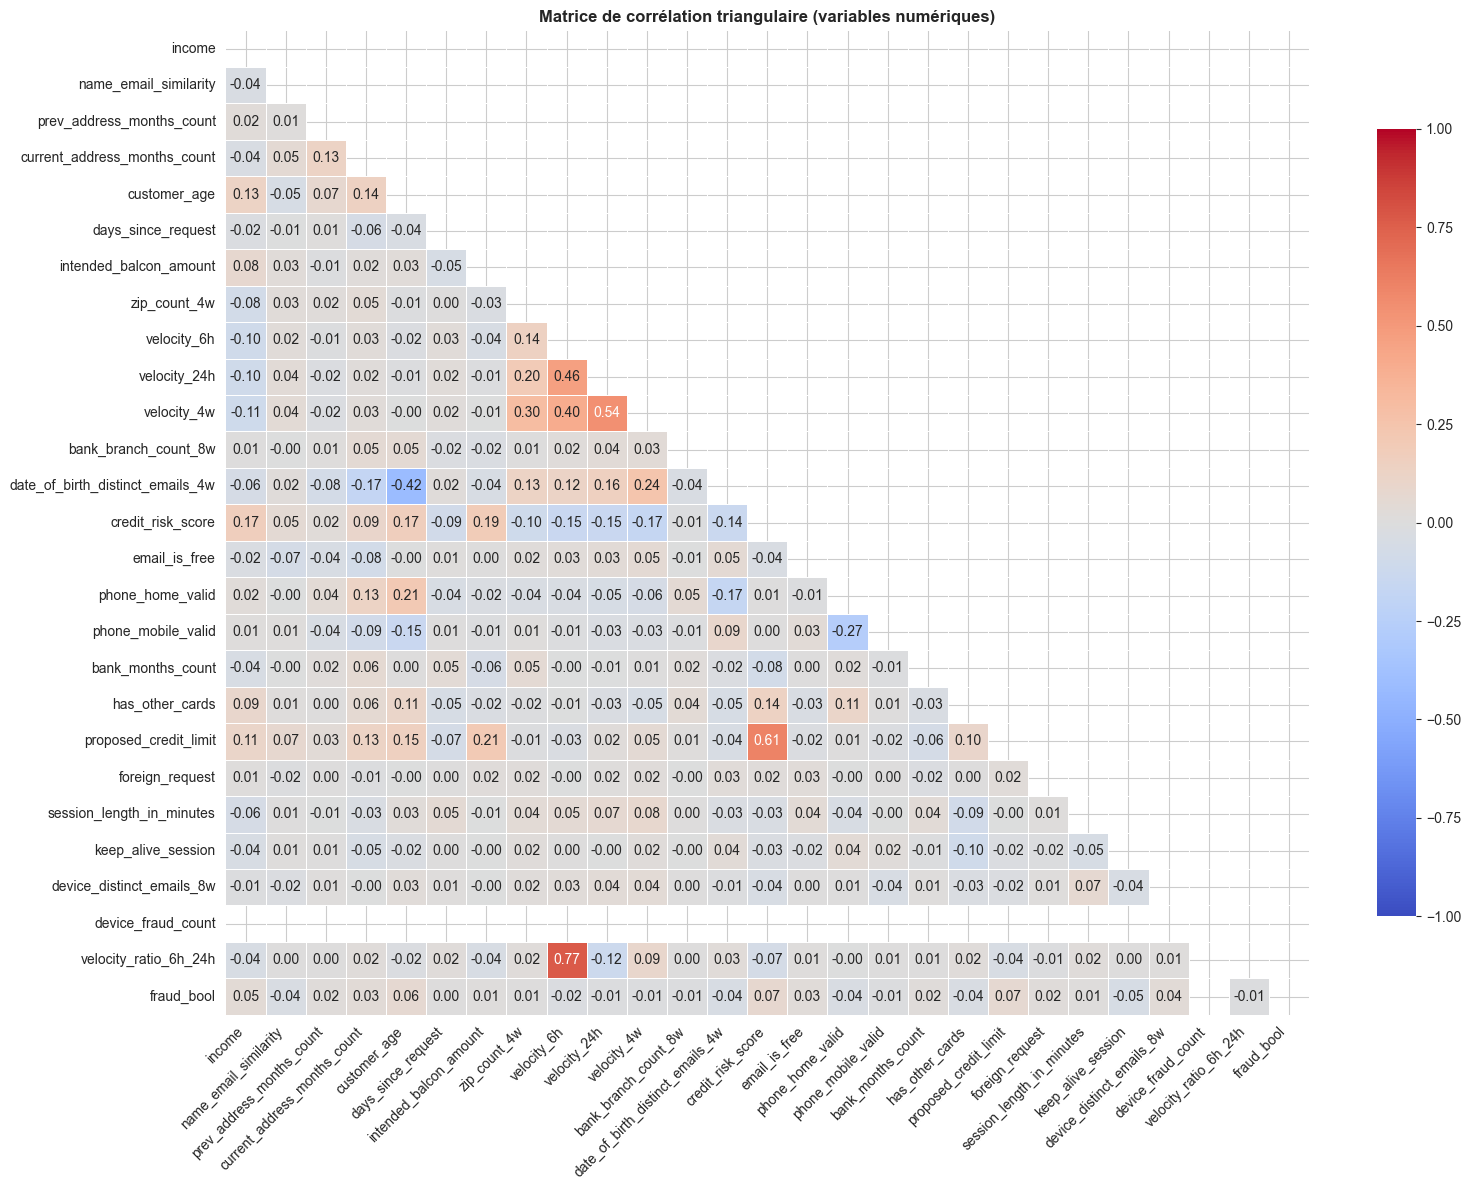

In [35]:
# Heatmap des corrélations entre variables numériques
num_cols = df.select_dtypes(include=np.number).columns.drop(['fraud_bool', 'month'])
corr = df[num_cols.tolist() + ['fraud_bool']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, fmt='.2f', linewidths=0.5, cbar_kws={'shrink': .8})
plt.title('Matrice de corrélation triangulaire (variables numériques)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/08_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

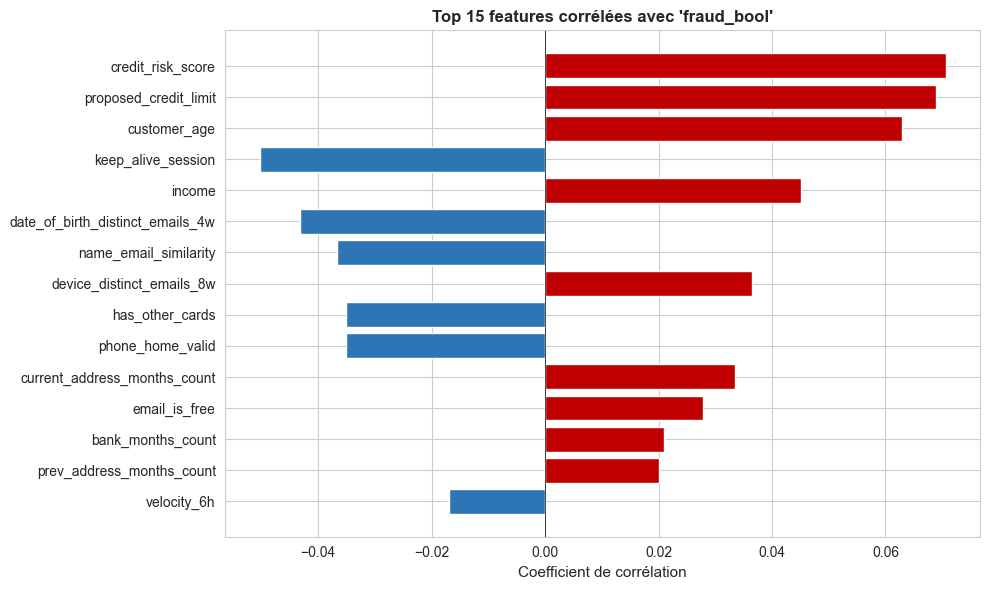

In [36]:
# Top features corrélées avec la cible (en absolu)
plot_correlation_with_target(df, target_col='fraud_bool', top_n=15,
                              save_path='../reports/figures/09_top_correlations.png')

## 10. Analyse fairness

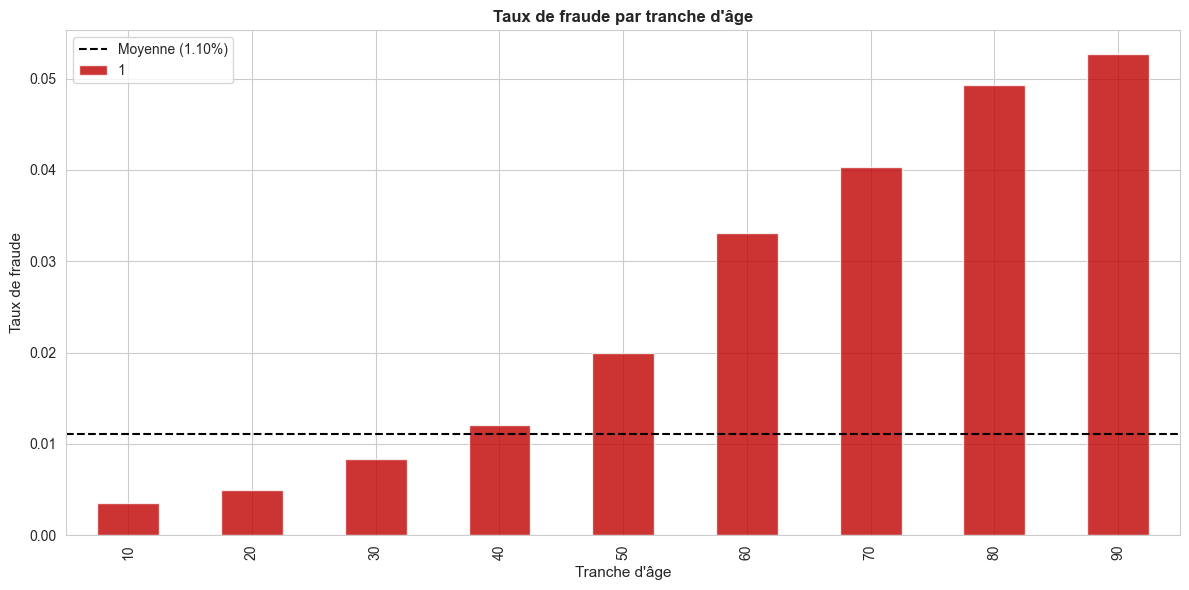

In [37]:
# Distribution de la fraude par tranche d'âge
fraud_by_age = pd.crosstab(df['customer_age'], df['fraud_bool'], normalize='index')

fig, ax = plt.subplots(figsize=(12, 6))
fraud_by_age[1].plot(kind='bar', ax=ax, color='#C00000', alpha=0.8)
ax.axhline(df['fraud_bool'].mean(), color='black', linestyle='--',
           label=f'Moyenne ({df.fraud_bool.mean():.2%})')
ax.set_title('Taux de fraude par tranche d\'âge',
             fontweight='bold')
ax.set_xlabel('Tranche d\'âge')
ax.set_ylabel('Taux de fraude')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/10_fraud_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Distribution par niveau de revenu
fraud_by_income = df.groupby(pd.cut(df['income'], bins=5))['fraud_bool'].agg(['mean', 'count'])
fraud_by_income

C:\Users\mikym\AppData\Local\Temp\ipykernel_9364\3055039883.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_income = df.groupby(pd.cut(df['income'], bins=5))['fraud_bool'].agg(['mean', 'count'])


,mean,count
income,,
"(0.0992, 0.26]",0.0059,226794
"(0.26, 0.42]",0.0071,132197
"(0.42, 0.58]",0.0079,55858
"(0.58, 0.74]",0.0088,217082
"(0.74, 0.9]",0.0174,368069


**Interprétation critique**

**Le taux de fraude augmente avec l'âge.** Ce résultat contre-intuitif est cohérent avec le contexte
bancaire : les personnes âgées sont souvent davantage ciblées par l'usurpation d'identité car elles
ont des scores de crédit plus établis, facilitant l'obtention de services bancaires.

**Implication pour la modélisation** : un modèle ML va probablement apprendre à flaguer davantage
les profils âgés, générant **plus de fausses alertes sur ce groupe**. C'est exactement le type de
biais qu'il faudra mesurer et corriger.

## Conclusion - Synthèse des décisions méthodologiques

L'EDA nous a permis de prendre **5 décisions méthodologiques clés** justifiées par les données :

| # | Observation | Décision pour la modélisation |
|---|-------------|-------------------------------|
| 1 | Déséquilibre extrême (~1%) | Métriques PR-AUC et Recall@5%FPR (jamais accuracy) |
| 2 | Dérive temporelle confirmée | Split temporel mois 0-5 / 6-7 (jamais aléatoire) |
| 3 | Relations non linéaires | Modèles à base d'arbres (XGBoost, LightGBM) en priorité |
| 4 | Hétérogénéité des features | LabelEncoder pour les arbres|
| 5 | Biais potentiel sur l'âge | Analyse fairness obligatoire post-modélisation |